# Gradient Boosting Regressor (GBR)

**Reduced feature set (feature extraction using PCA)**

Author: Pete King

Here we introduce a reduced feature set produced using Principal Component Analysis (PCA) and compare results to a GBR using the full feature set.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    make_scorer,
    r2_score,
    mean_absolute_error,
    root_mean_squared_error,
    mean_squared_error
)
from sklearn.model_selection import (
    TimeSeriesSplit,
    GridSearchCV
)
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import plot_tree

from helpers import data_prep as dp

IMAGE_DIR = Path.cwd() / 'images'
DATA_DIR = Path.cwd().parent / 'data' / 'train-val-test'
TRAIN_DATA_FILE = DATA_DIR / 'train_etf_data.csv'
PCA_TRAIN_DATA_FILE = DATA_DIR / 'train_PCA_data.csv'
VAL_DATA_FILE = DATA_DIR / 'val_etf_data.csv'
PCA_VAL_DATA_FILE = DATA_DIR / 'val_PCA_data.csv'
TICKER = 'SPY'

## I. Import data


In [2]:
# Combine PCA data with base data. From base data, select only historical 
# volatility and future volatility target.
train_df = dp.make_pca_df(TRAIN_DATA_FILE, PCA_TRAIN_DATA_FILE, TICKER)
val_df = dp.make_pca_df(VAL_DATA_FILE, PCA_VAL_DATA_FILE, TICKER)
train_df

,SPY_vol-h,SPY_vol_target,PCA_vol-1,PCA_vol-2,PCA_macro-1,PCA_macro-2,PCA_macro-3,PCA_macro-4,PCA_hvol-1,PCA_hvol-2,PCA_hvol-3,PCA_hret-1,PCA_hret-2,PCA_hret-3
date,,,,,,,,,,,,,,
2015-10-15,0.007701,0.007586,-0.007520,-0.017314,-0.043684,-0.032462,-0.030379,-0.060332,-0.049247,-0.045121,-0.042721,-0.051108,-0.030138,-0.026966
2015-10-16,0.007959,0.008211,-0.035560,-0.031620,0.003971,-0.004365,-0.028710,-0.019565,-0.042536,-0.040873,-0.026386,-0.008257,-0.036894,-0.000262
2015-10-19,0.007951,0.008211,-0.024012,-0.029969,-0.043351,-0.038941,-0.035658,-0.048344,-0.050392,-0.037353,-0.043544,-0.024586,0.013132,-0.043831
2015-10-20,0.007453,0.008897,-0.037603,-0.007127,0.011081,0.006980,0.076445,0.080881,0.071050,-0.022265,-0.023854,-0.006707,-0.033878,-0.052647
2015-10-21,0.007660,0.008794,-0.068045,-0.069615,-0.046138,-0.056662,-0.043457,-0.030918,0.005319,0.010031,0.023756,0.088866,0.088049,0.062458
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-11-25,0.007099,0.012897,0.258337,0.149808,0.086959,0.134713,0.083816,0.120398,0.109066,0.155611,0.038508,0.113100,0.177111,0.175406
2022-11-28,0.009902,0.012706,0.096378,0.304708,0.249026,0.125419,0.126457,0.059525,0.060945,0.058034,0.060801,0.051126,0.251974,0.079012
2022-11-29,0.009797,0.013284,0.056107,0.136835,0.142917,0.097348,0.113664,0.137253,0.162015,0.235244,0.181824,0.164834,0.233196,0.160890


In [3]:
val_df

,SPY_vol-h,SPY_vol_target,PCA_vol-1,PCA_vol-2,PCA_macro-1,PCA_macro-2,PCA_macro-3,PCA_macro-4,PCA_hvol-1,PCA_hvol-2,PCA_hvol-3,PCA_hret-1,PCA_hret-2,PCA_hret-3
date,,,,,,,,,,,,,,
2023-01-03,0.010149,0.011025,0.453148,0.416874,0.381460,0.326747,0.354667,0.360351,0.337249,0.291625,0.291295,0.358607,0.305738,0.317716
2023-01-04,0.010569,0.011143,0.311262,0.311023,0.294998,0.261813,0.240430,0.213455,0.250893,0.217927,0.185115,0.198519,0.206457,0.258115
2023-01-05,0.010334,0.010940,0.235466,0.230937,0.254731,0.296965,0.303737,0.282520,0.260512,0.297815,0.289761,0.382723,0.367265,0.349193
2023-01-06,0.012081,0.010161,0.388954,0.363824,0.384132,0.367676,0.377511,0.353356,0.390025,0.430805,0.401760,0.431728,0.521280,0.756046
2023-01-09,0.012026,0.010439,0.699941,0.724340,0.684554,0.786740,0.791232,0.633942,0.518006,0.575002,0.709899,0.622068,0.578389,0.536066
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-26,0.006228,0.008510,0.269193,0.399177,0.442251,0.389744,0.436800,0.429523,0.436500,0.402717,0.451624,0.453634,0.566088,0.422893
2024-08-27,0.006215,0.008549,0.355320,0.331270,0.325174,0.329951,0.407954,0.455222,0.523995,0.572949,0.517990,0.351693,0.406278,0.301033
2024-08-28,0.006562,0.008460,0.360400,0.362854,0.350842,0.386665,0.407895,0.364216,0.368343,0.375393,0.376518,0.322217,0.410650,0.298538


In [4]:
# Separate features from labels; discard daily returns as a feature. Note 
# that we capture recent returns (past 2-weeks) in one of the PCA features.
data_cols, _ = dp.get_X_y_cols(train_df, returns=False)
label_col = [TICKER + '_vol_target']
# Training set
X_train = train_df.dropna()[data_cols].astype(np.float32)
y_train = train_df.dropna()[label_col].astype(np.float32).values.reshape(-1,)
# Validation set
X_val = val_df.dropna()[data_cols].astype(np.float32)
y_val = val_df.dropna()[label_col].astype(np.float32).values.reshape(-1,)
# Define time series cross-validation split
ts_cv = TimeSeriesSplit(
    n_splits=3,
    test_size=252,
    gap=21
)

## II. Define model, fit to data, and evaluate performance

Here we use the same parameters from our grid search using the full feature set.

In [5]:
# Define model, metrics, and Grid Search for hyperparameter tuning
reg = GradientBoostingRegressor(
    loss='absolute_error',
    learning_rate=0.01,
    max_features='sqrt',
    max_depth=2,
    n_estimators=1000
)

In [6]:
reg.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'absolute_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.01
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",1000
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",2
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in thele

### Visualize performance; Check evaluation metrics

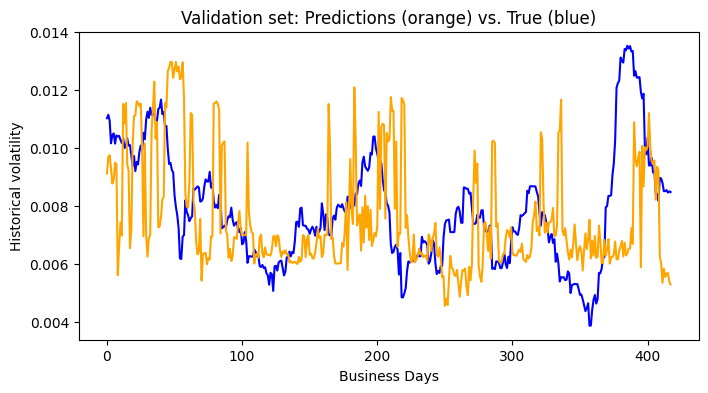

In [7]:
# Use the best estimator to make predictions on the validation set
# best = reg.best_estimator_
preds = reg.predict(X_val)
x = range(len(y_val))

fig = plt.figure(figsize=(8, 4))
ax = fig.subplots()
ax.set_title('Validation set: Predictions (orange) vs. True (blue)')
ax.set_ylabel('Historical volatility')
ax.set_xlabel('Business Days')
ax.plot(x, y_val, color='blue')
ax.plot(x, preds, color='orange')
fig.savefig(IMAGE_DIR / 'D-GBR-PCA')

In [8]:
print(f'MAE: {mean_absolute_error(y_val, preds)}')
print(f'R2: {r2_score(y_val, preds)}')

MAE: 0.0018340224516397515
R2: -0.5710185258288616


Looking at the plot of predictions vs. labels, it is not immediately clear how well the PCA features aid the model in making accurate predictions.  Predictions from the GBR using PCA features appear much more erratic than those from the GBR with the full feature set.  According to our metrics, however, both MAE and R-squared improved (MAE down from 0.0027 to 0.0018, R-squared up from -1.59 to -0.57) compared to a GBR model using the full feature set.  With R-squared below zero, however, the model's predictions are still worse than simply guessing the mean value.  Due to the temporal lag, the model is typically heading in the wrong direction, predicting a spike well after volatility has already spiked and is declining back to a lower baseline.

We also note that while MAE here is similar to the Ridge model using PCA, the Ridge model actually outperforms the GBR slightly in R-squared (-0.46 for Ridge vs. -0.57 for GBR).  Both models exhibit a lag in predictions that cause R-squared to be worse than simply guessing at a mean value.

## III. Inspect model


In [9]:
feature_importances = list(
    zip(reg.feature_names_in_, reg.feature_importances_)
)
for feature, coef in sorted(feature_importances, key=lambda i: -i[1]):
    print(f'{feature}: {coef:2.3f}')

SPY_vol-h: 0.693
PCA_vol-1: 0.046
PCA_macro-2: 0.035
PCA_hret-1: 0.030
PCA_hvol-3: 0.027
PCA_hvol-2: 0.026
PCA_vol-2: 0.024
PCA_macro-3: 0.023
PCA_macro-4: 0.023
PCA_hret-3: 0.022
PCA_macro-1: 0.019
PCA_hvol-1: 0.017
PCA_hret-2: 0.014


Similar to the Ridge regressor using extracted features, near-term historical volatility of the asset (SPY_vol-h) is the most important feature in this GBR's decision-making process.